```
06-feature-detection/
│
├── 01. Feature Points
│
├── 02. Harris Corner Detection
│
├── 03. Shi-Tomasi
│
├── 04. SIFT
│
├── 05. ORB
│
├── 06. Descriptors
│
├── 07. Feature Matching
│     ├── BFMatcher
│     └── FLANN
│
├── 08. Match Filtering
│     └── Lowe's Ratio Test
│
├── 09. Homography
│     └── RANSAC
│
├── 10. Template Matching
│
└── 11. Mini Project

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

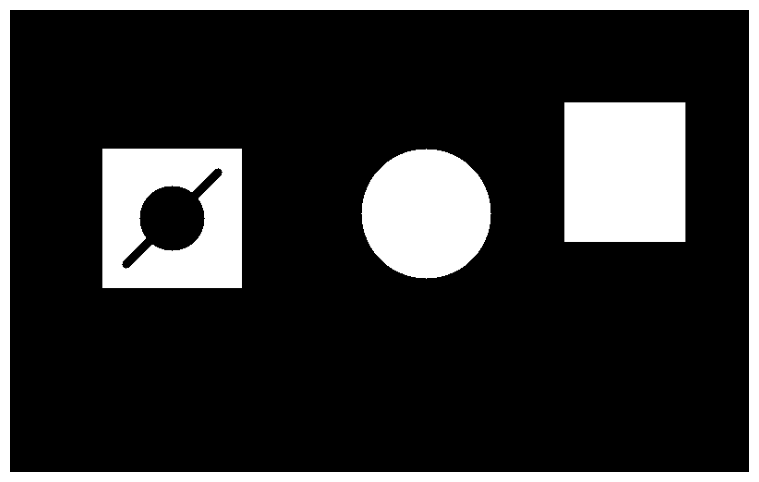

In [2]:
scene1 = np.zeros((500, 800, 3), dtype=np.uint8)

# Target object
cv2.rectangle(scene1, (100, 150), (250, 300), (255, 255, 255), -1)

# Unique pattern inside target
cv2.circle(scene1, (175, 225), 35, (0, 0, 0), -1)
cv2.line(scene1, (125, 275), (225, 175), (0, 0, 0), 8)

# Other objects
cv2.circle(scene1, (450, 220), 70, (255, 255, 255), -1)

cv2.rectangle(
    scene1,
    (600, 100),
    (730, 250),
    (255, 255, 255),
    -1
)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(scene1, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [3]:
template = scene1[150:300, 100:250] # image[y1:y2, x1:x2]

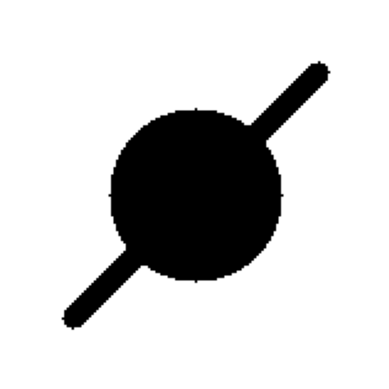

In [4]:
plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

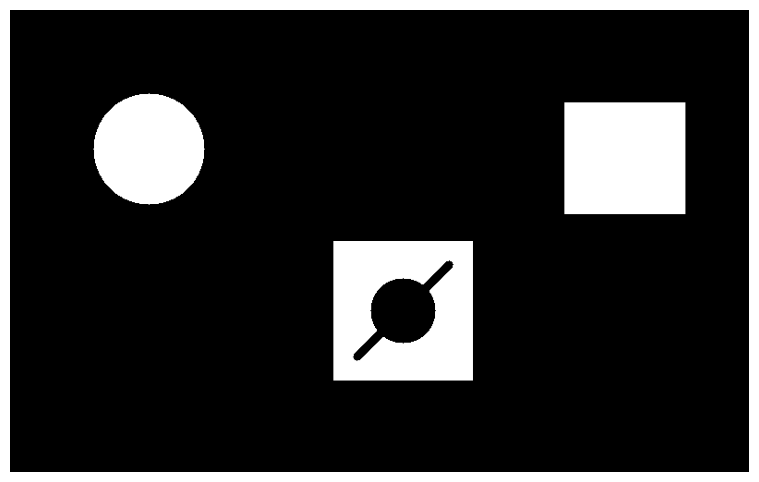

In [5]:
scene2 = np.zeros((500, 800, 3), dtype=np.uint8)

# Same target object, moved to another location
cv2.rectangle(scene2, (350, 250), (500, 400), (255, 255, 255), -1)

# Same internal pattern
cv2.circle(scene2, (425, 325), 35, (0, 0, 0), -1)
cv2.line(scene2, (375, 375), (475, 275), (0, 0, 0), 8)

# Distractor objects
cv2.circle(scene2, (150, 150), 60, (255, 255, 255), -1)

cv2.rectangle(
    scene2,
    (600, 100),
    (730, 220),
    (255, 255, 255),
    -1
)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(scene2, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [6]:
result = cv2.matchTemplate(
    scene2,
    template,
    cv2.TM_CCOEFF_NORMED
)

In [7]:
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

print("Minimum score:", min_val)
print("Maximum score:", max_val)
print("Best location:", max_loc)

Minimum score: -0.5192511677742004
Maximum score: 1.0
Best location: (350, 250)


In [8]:
h, w = template.shape[:2]

print("Template width:", w)
print("Template height:", h)

Template width: 150
Template height: 150


In [9]:
threshold = 0.8

if max_val >= threshold:
    print(f"Object found! Confidence: {max_val:.3f}")
else:
    print(f"Object not found. Confidence: {max_val:.3f}")

Object found! Confidence: 1.000


In [10]:
output = scene2.copy()

if max_val >= threshold:

    top_left = max_loc

    bottom_right = (
        top_left[0] + w,
        top_left[1] + h
    )

    cv2.rectangle(
        output,
        top_left,
        bottom_right,
        (0, 255, 0),
        3
    )

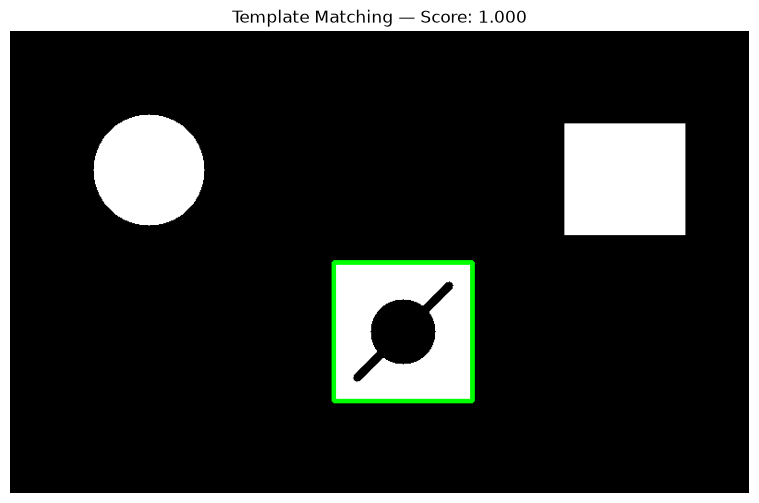

In [11]:
plt.figure(figsize=(12, 6))

plt.imshow(
    cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
)

plt.title(f"Template Matching — Score: {max_val:.3f}")
plt.axis("off");

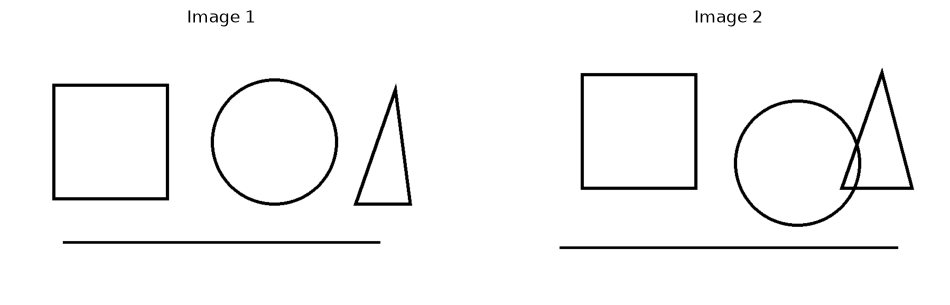

In [12]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("assets/feature_points_shapes_1.png")
img2 = cv2.imread("assets/feature_points_shapes_2.png")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray1, cmap="gray")
plt.title("Image 1")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray2, cmap="gray")
plt.title("Image 2")
plt.axis("off");

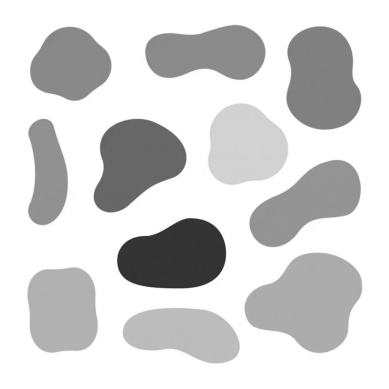

In [13]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("assets/image.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.axis("off");

In [14]:
corners = cv2.cornerHarris(
    gray,
    blockSize=2,
    ksize=3,
    k=0.04
)

In [15]:
threshold = 0.01 * corners.max()

img_result = img.copy()

img_result[corners > threshold] = [0, 0, 255]

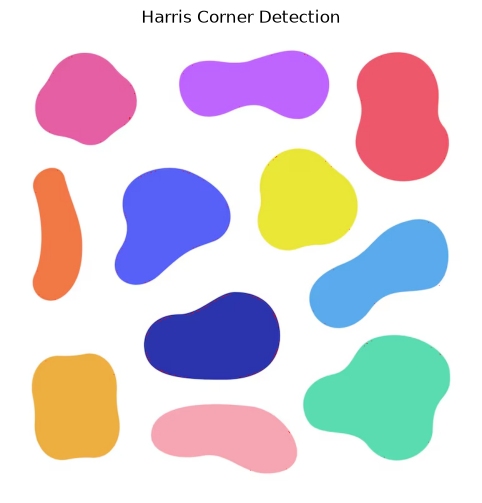

In [16]:
plt.figure(figsize=(10, 6))

plt.imshow(cv2.cvtColor(img_result, cv2.COLOR_BGR2RGB))
plt.title("Harris Corner Detection")
plt.axis("off");

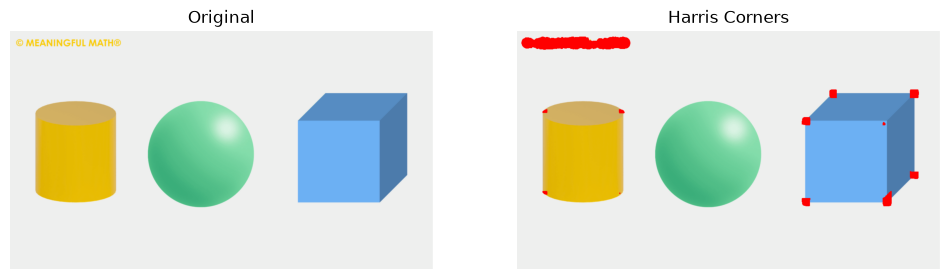

In [31]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("assets/image.png")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

corners = cv2.cornerHarris(
    gray,
    blockSize=20,
    ksize=3,
    k=0.04
)

corners = cv2.dilate(corners, None)

result = img.copy()

result[corners > 0.01 * corners.max()] = [0, 0, 255]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Harris Corners")
plt.axis("off");

In [28]:
corners.shape

(576, 1024)

In [19]:
img.shape

(500, 800, 3)

In [20]:
corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=50,
    qualityLevel=0.01,
    minDistance=10
)

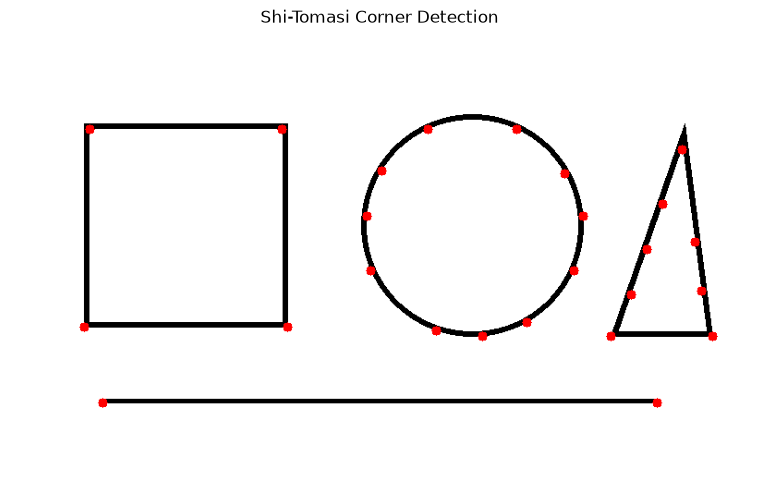

In [21]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("assets/feature_points_shapes_1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

corners = cv2.goodFeaturesToTrack(
    gray,
    maxCorners=50,
    qualityLevel=0.01,
    minDistance=50
)

corners = corners.astype(int)

result = img.copy()

for corner in corners:
    x, y = corner.ravel()

    cv2.circle(
        result,
        (x, y),
        5,
        (0, 0, 255),
        -1
    )

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Shi-Tomasi Corner Detection")
plt.axis("off");

In [22]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("assets/feature_points_shapes_1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

keypoints, descriptors = sift.detectAndCompute(
    gray,
    None
)

In [23]:
keypoints, descriptors = sift.detectAndCompute(gray, None)

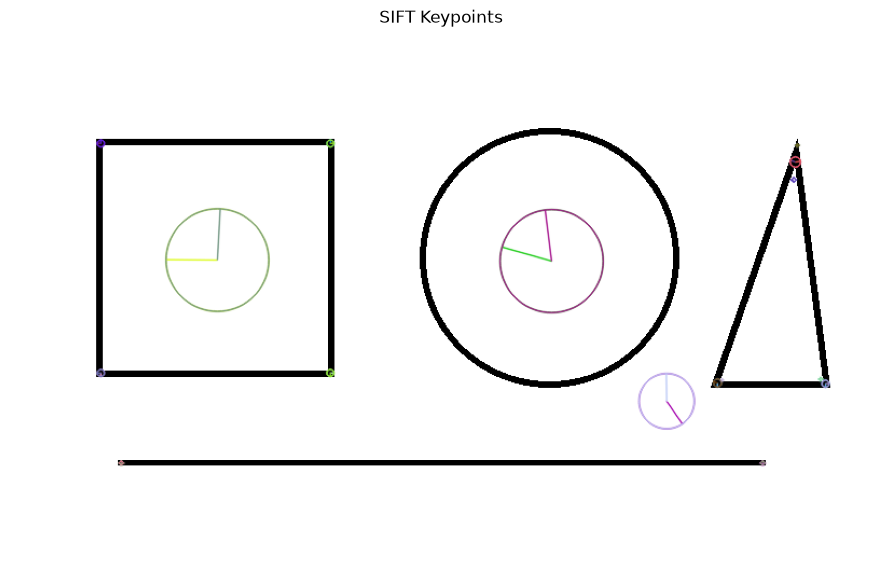

In [24]:
result = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("SIFT Keypoints")
plt.axis("off");

In [25]:
orb = cv2.ORB_create(nfeatures=50)

keypoints, descriptors = orb.detectAndCompute(
    gray,
    None
)

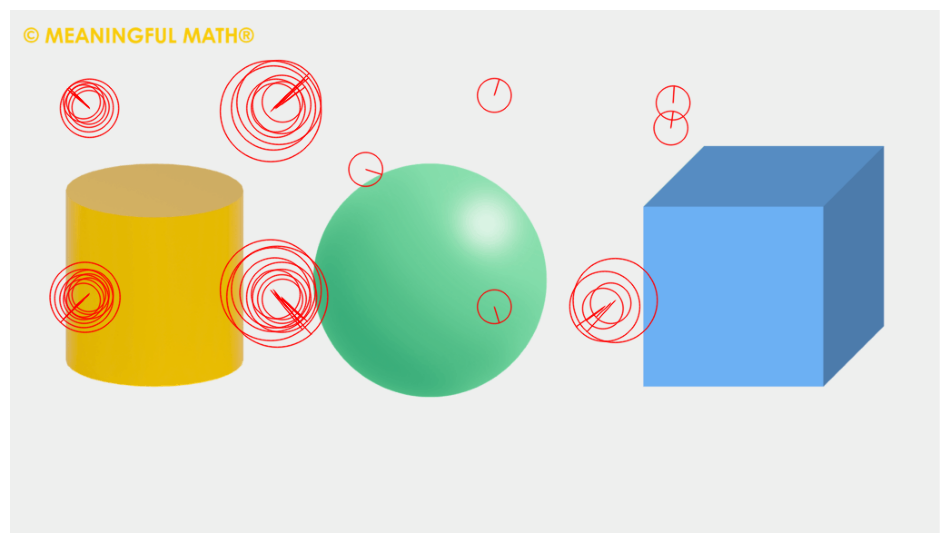

In [35]:
result = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    color=(0, 0, 255),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off");

In [36]:
import cv2
import matplotlib.pyplot as plt

img1 = cv2.imread("assets/feature_points_shapes_1.png")
img2 = cv2.imread("assets/feature_points_shapes_2.png")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(nfeatures=500)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

print("Image 1:", len(kp1), "features")
print("Image 2:", len(kp2), "features")

Image 1: 380 features
Image 2: 392 features


In [37]:
matcher = cv2.BFMatcher(
    cv2.NORM_HAMMING,
    crossCheck=True
)

In [38]:
matches = matcher.match(des1, des2)

In [39]:
matches = sorted(matches, key=lambda x: x.distance)

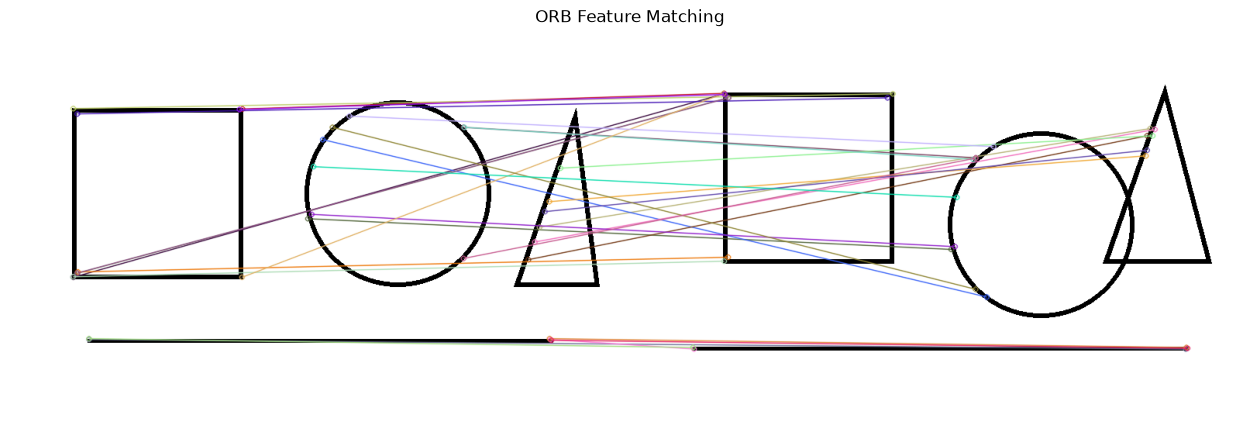

In [40]:
result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    matches[:30],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matching")
plt.axis("off");

In [41]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(
    des1,
    des2,
    k=2
)

In [42]:
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

In [43]:
m.distance < 0.75 * n.distance

False

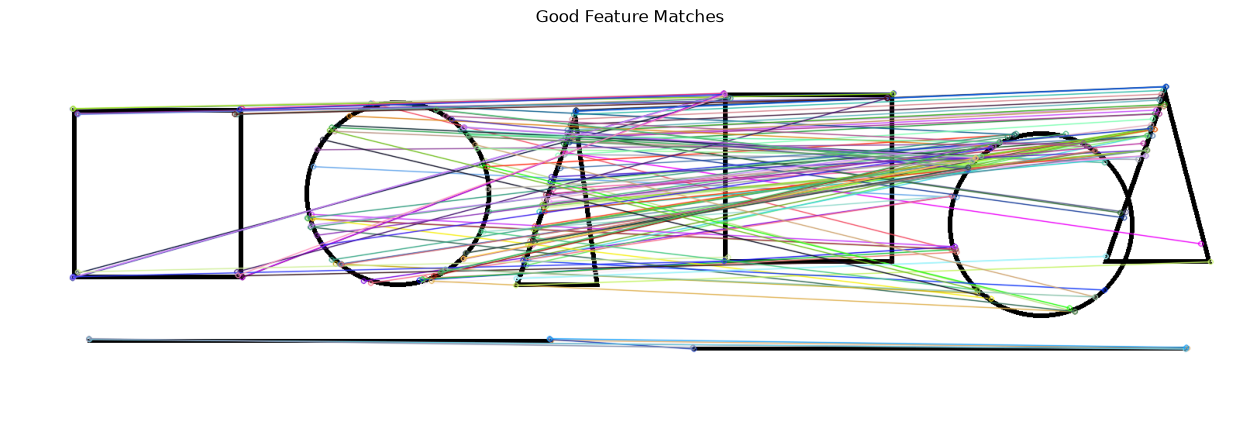

In [44]:
result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Good Feature Matches")
plt.axis("off");

In [45]:
import numpy as np

src_pts = np.float32([
    kp1[m.queryIdx].pt
    for m in good_matches
]).reshape(-1, 1, 2)

dst_pts = np.float32([
    kp2[m.trainIdx].pt
    for m in good_matches
]).reshape(-1, 1, 2)

In [46]:
H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    cv2.RANSAC,
    5.0
)

In [47]:
inlier_matches = [
    m for m, keep in zip(good_matches, mask.ravel())
    if keep
]

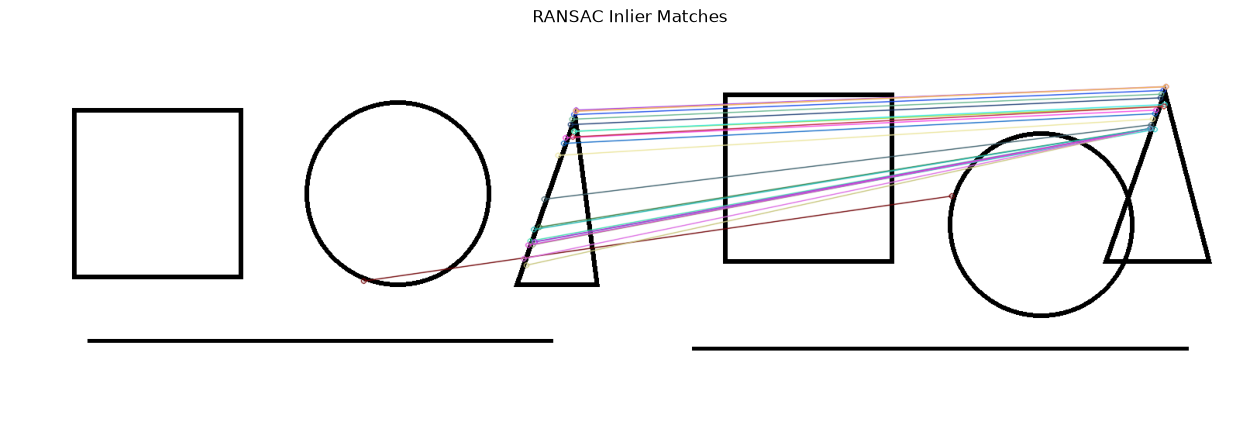

In [48]:
result = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    inlier_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("RANSAC Inlier Matches")
plt.axis("off");

In [49]:
h, w = img1.shape[:2]

object_corners = np.float32([
    [0, 0],
    [w, 0],
    [w, h],
    [0, h]
]).reshape(-1, 1, 2)

In [50]:
H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    cv2.RANSAC,
    5.0
)

In [51]:
projected_corners = cv2.perspectiveTransform(
    object_corners,
    H
)

In [52]:
result = img2.copy()

cv2.polylines(
    result,
    [np.int32(projected_corners)],
    True,
    (0, 0, 255),
    4
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

Good matches: 140


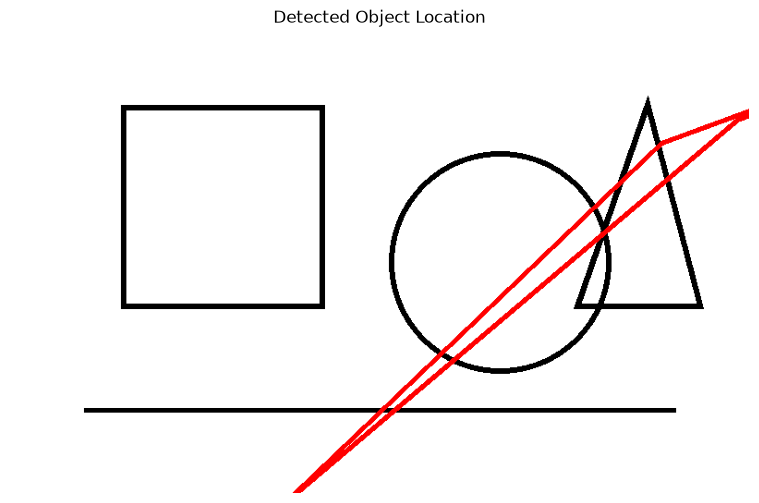

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img1 = cv2.imread("assets/feature_points_shapes_1.png")
img2 = cv2.imread("assets/feature_points_shapes_2.png")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# 1. ORB
orb = cv2.ORB_create(nfeatures=500)

kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

# 2. KNN Matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(des1, des2, k=2)

# 3. Lowe Ratio Test
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print("Good matches:", len(good_matches))

# 4. Match coordinates
src_pts = np.float32([
    kp1[m.queryIdx].pt
    for m in good_matches
]).reshape(-1, 1, 2)

dst_pts = np.float32([
    kp2[m.trainIdx].pt
    for m in good_matches
]).reshape(-1, 1, 2)

# 5. Homography + RANSAC
H, mask = cv2.findHomography(
    src_pts,
    dst_pts,
    cv2.RANSAC,
    5.0
)

# 6. Image 1 object = entire image
h, w = img1.shape[:2]

object_corners = np.float32([
    [0, 0],
    [w, 0],
    [w, h],
    [0, h]
]).reshape(-1, 1, 2)

# 7. Project object into Image 2
projected_corners = cv2.perspectiveTransform(
    object_corners,
    H
)

# 8. Draw location
result = img2.copy()

cv2.polylines(
    result,
    [np.int32(projected_corners)],
    True,
    (0, 0, 255),
    4
)

# 9. Display
plt.figure(figsize=(12, 6))

plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Detected Object Location")
plt.axis("off");

In [54]:
import cv2
import matplotlib.pyplot as plt

scene = cv2.imread("assets/feature_points_shapes_2.png")

template = cv2.imread("assets/feature_points_shapes_1.png")

print(scene.shape)
print(template.shape)

(500, 800, 3)
(500, 800, 3)


In [55]:
template = cv2.imread(
    "assets/feature_points_shapes_1.png"
)[100:320, 80:300]

In [56]:
gray_scene = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
gray_template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

result = cv2.matchTemplate(
    gray_scene,
    gray_template,
    cv2.TM_CCOEFF_NORMED
)

In [57]:
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

print("Best score:", max_val)
print("Best location:", max_loc)

Best score: 1.0
Best location: (120, 80)


In [58]:
h, w = template.shape[:2]

top_left = max_loc

bottom_right = (
    top_left[0] + w,
    top_left[1] + h
)

cv2.rectangle(
    scene,
    top_left,
    bottom_right,
    (0, 0, 255),
    3
)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

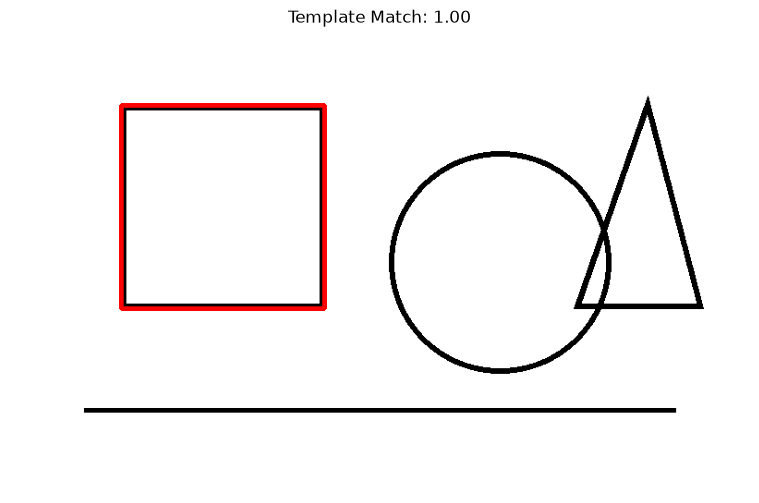

In [59]:
plt.figure(figsize=(12, 6))

plt.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
plt.title(f"Template Match: {max_val:.2f}")
plt.axis("off");

```
                    FEATURE DETECTION
                           │
        ┌──────────────────┴──────────────────┐
        ↓                                     ↓
  CORNER DETECTION                     FEATURE DETECTION
        │                                     │
   Harris / Shi-Tomasi                    SIFT / ORB
                                              │
                                              ↓
                                       Descriptors
                                              │
                                              ↓
                                       BF / FLANN
                                              │
                                              ↓
                                      Lowe Ratio Test
                                              │
                                              ↓
                                       Homography
                                              │
                                              ↓
                                         RANSAC
                                              │
                                              ↓
                                      Object Location


              TEMPLATE MATCHING
                     │
              Template + Scene
                     ↓
              matchTemplate()
                     ↓
              Best similarity
                     ↓
              Object Location

In [61]:
cap = cv2.VideoCapture("assets/people-walking.mp4")

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # ORB feature detection
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    keypoints, descriptors = orb.detectAndCompute(
        gray,
        None
    )

    frame = cv2.drawKeypoints(
        frame,
        keypoints,
        None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )

    cv2.imshow("Feature Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

In [64]:
import cv2

# =========================
# 1. Open video
# =========================

cap = cv2.VideoCapture("assets/people-walking.mp4")

ret, first_frame = cap.read()

if not ret:
    raise ValueError("Could not read video")


# =========================
# 2. Select object manually
# =========================

roi = cv2.selectROI(
    "Select Person",
    first_frame,
    fromCenter=False,
    showCrosshair=True
)

x, y, w, h = roi

# User pressed ENTER/SPACE without selecting
if w == 0 or h == 0:
    cap.release()
    cv2.destroyAllWindows()
    raise ValueError("No object selected")


# Crop selected person
template = first_frame[y:y+h, x:x+w]

gray_template = cv2.cvtColor(
    template,
    cv2.COLOR_BGR2GRAY
)


# =========================
# 3. Process video
# =========================

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray_frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    # =========================
    # 4. Template Matching
    # =========================

    result = cv2.matchTemplate(
        gray_frame,
        gray_template,
        cv2.TM_CCOEFF_NORMED
    )

    # Find best match
    _, max_val, _, max_loc = cv2.minMaxLoc(result)

    # =========================
    # 5. Draw bounding box
    # =========================

    if max_val > 0.6:

        top_left = max_loc

        bottom_right = (
            top_left[0] + w,
            top_left[1] + h
        )

        cv2.rectangle(
            frame,
            top_left,
            bottom_right,
            (0, 255, 0),
            3
        )

        cv2.putText(
            frame,
            f"Confidence: {max_val:.2f}",
            (top_left[0], top_left[1] - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    # Show frame
    cv2.imshow(
        "Object Tracking",
        frame
    )

    # Press Q to quit
    if cv2.waitKey(30) & 0xFF == ord("q"):
        break


# =========================
# 6. Cleanup
# =========================

cap.release()
cv2.destroyAllWindows()

In [66]:
import cv2
import numpy as np

# ============================================================
# 1. OPEN VIDEO
# ============================================================

video_path = "assets/people-walking.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("Could not open video")


# ============================================================
# 2. READ FIRST FRAME
# ============================================================

ret, first_frame = cap.read()

if not ret:
    cap.release()
    raise ValueError("Could not read first frame")


# ============================================================
# 3. SELECT PERSON
# ============================================================

x, y, w, h = cv2.selectROI(
    "Select Person",
    first_frame,
    fromCenter=False,
    showCrosshair=True
)

cv2.destroyWindow("Select Person")

if w == 0 or h == 0:
    cap.release()
    raise ValueError("No object selected")


# Save original template
template = first_frame[y:y+h, x:x+w]

template_gray = cv2.cvtColor(
    template,
    cv2.COLOR_BGR2GRAY
)


# Current object position
current_x = x
current_y = y
current_w = w
current_h = h


# ============================================================
# PARAMETERS
# ============================================================

# Different template sizes
scales = np.linspace(0.70, 1.30, 13)

# Minimum confidence
MIN_CONFIDENCE = 0.55

# Search area expansion
SEARCH_SCALE = 2.5


# ============================================================
# 4. FRAME-BY-FRAME TRACKING
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        break


    frame_gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    frame_h, frame_w = frame_gray.shape


    # ========================================================
    # SEARCH REGION
    # ========================================================

    center_x = current_x + current_w // 2
    center_y = current_y + current_h // 2

    search_w = int(current_w * SEARCH_SCALE)
    search_h = int(current_h * SEARCH_SCALE)

    search_x1 = max(
        0,
        center_x - search_w // 2
    )

    search_y1 = max(
        0,
        center_y - search_h // 2
    )

    search_x2 = min(
        frame_w,
        center_x + search_w // 2
    )

    search_y2 = min(
        frame_h,
        center_y + search_h // 2
    )

    search_region = frame_gray[
        search_y1:search_y2,
        search_x1:search_x2
    ]


    # ========================================================
    # MULTI-SCALE TEMPLATE MATCHING
    # ========================================================

    best_score = -1
    best_location = None
    best_size = None


    for scale in scales:

        new_w = int(
            template_gray.shape[1] * scale
        )

        new_h = int(
            template_gray.shape[0] * scale
        )

        # Template must fit inside search region
        if (
            new_w < 20
            or new_h < 20
            or new_w > search_region.shape[1]
            or new_h > search_region.shape[0]
        ):
            continue


        resized_template = cv2.resize(
            template_gray,
            (new_w, new_h),
            interpolation=cv2.INTER_LINEAR
        )


        result = cv2.matchTemplate(
            search_region,
            resized_template,
            cv2.TM_CCOEFF_NORMED
        )


        _, max_val, _, max_loc = cv2.minMaxLoc(
            result
        )


        if max_val > best_score:

            best_score = max_val

            best_location = max_loc

            best_size = (
                new_w,
                new_h
            )


    # ========================================================
    # CHECK RESULT
    # ========================================================

    if (
        best_location is not None
        and best_score >= MIN_CONFIDENCE
    ):

        match_x = (
            search_x1 + best_location[0]
        )

        match_y = (
            search_y1 + best_location[1]
        )

        match_w, match_h = best_size


        # Update current position
        current_x = match_x
        current_y = match_y
        current_w = match_w
        current_h = match_h


        # Draw tracking box
        cv2.rectangle(
            frame,
            (
                current_x,
                current_y
            ),
            (
                current_x + current_w,
                current_y + current_h
            ),
            (0, 255, 0),
            3
        )


        # Status
        cv2.putText(
            frame,
            f"TRACKING  {best_score:.2f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 255, 0),
            2
        )


    else:

        # Don't change position if match is unreliable

        cv2.rectangle(
            frame,
            (
                current_x,
                current_y
            ),
            (
                current_x + current_w,
                current_y + current_h
            ),
            (0, 165, 255),
            2
        )


        cv2.putText(
            frame,
            f"LOW CONFIDENCE  {best_score:.2f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 165, 255),
            2
        )


    # ========================================================
    # SHOW VIDEO
    # ========================================================

    cv2.imshow(
        "Multi-Scale Template Tracking",
        frame
    )


    # Q = quit
    if cv2.waitKey(30) & 0xFF == ord("q"):
        break


# ============================================================
# CLEANUP
# ============================================================

cap.release()
cv2.destroyAllWindows()

In [67]:
import cv2
import numpy as np


# ============================================================
# 1. VIDEO
# ============================================================

VIDEO_PATH = "assets/people-walking.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise ValueError("Could not open video")


# ============================================================
# 2. FIRST FRAME + SELECT OBJECT
# ============================================================

ret, first_frame = cap.read()

if not ret:
    cap.release()
    raise ValueError("Could not read first frame")


x, y, w, h = cv2.selectROI(
    "Select Person",
    first_frame,
    fromCenter=False,
    showCrosshair=True
)

cv2.destroyWindow("Select Person")

if w == 0 or h == 0:
    cap.release()
    raise ValueError("No object selected")


# ============================================================
# 3. CREATE TEMPLATE
# ============================================================

template = first_frame[y:y+h, x:x+w]

template_gray = cv2.cvtColor(
    template,
    cv2.COLOR_BGR2GRAY
)


# Current position
current_x = x
current_y = y
current_w = w
current_h = h


# ============================================================
# 4. PARAMETERS
# ============================================================

# Scale changes
SCALES = np.linspace(0.70, 1.30, 13)

# Minimum acceptable similarity
MIN_CONFIDENCE = 0.55

# Search area around previous position
SEARCH_SCALE = 2.5


# ============================================================
# 5. FRAME-BY-FRAME TRACKING
# ============================================================

while True:

    ret, frame = cap.read()

    if not ret:
        break


    gray = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2GRAY
    )

    frame_h, frame_w = gray.shape


    # ========================================================
    # SEARCH REGION
    # ========================================================

    center_x = current_x + current_w // 2
    center_y = current_y + current_h // 2

    search_w = int(current_w * SEARCH_SCALE)
    search_h = int(current_h * SEARCH_SCALE)

    search_x1 = max(
        0,
        center_x - search_w // 2
    )

    search_y1 = max(
        0,
        center_y - search_h // 2
    )

    search_x2 = min(
        frame_w,
        center_x + search_w // 2
    )

    search_y2 = min(
        frame_h,
        center_y + search_h // 2
    )

    search_region = gray[
        search_y1:search_y2,
        search_x1:search_x2
    ]


    # ========================================================
    # MULTI-SCALE TEMPLATE MATCHING
    # ========================================================

    best_score = -1
    best_location = None
    best_size = None


    for scale in SCALES:

        new_w = int(
            template_gray.shape[1] * scale
        )

        new_h = int(
            template_gray.shape[0] * scale
        )

        # Template must fit inside search region
        if (
            new_w < 20
            or new_h < 20
            or new_w > search_region.shape[1]
            or new_h > search_region.shape[0]
        ):
            continue


        resized_template = cv2.resize(
            template_gray,
            (new_w, new_h),
            interpolation=cv2.INTER_LINEAR
        )


        result = cv2.matchTemplate(
            search_region,
            resized_template,
            cv2.TM_CCOEFF_NORMED
        )


        _, max_val, _, max_loc = cv2.minMaxLoc(
            result
        )


        # Keep the best scale
        if max_val > best_score:

            best_score = max_val

            best_location = max_loc

            best_size = (
                new_w,
                new_h
            )


    # ========================================================
    # CONFIDENCE CHECK
    # ========================================================

    if (
        best_location is not None
        and best_score >= MIN_CONFIDENCE
    ):

        # Convert search-region coordinates
        # to full-frame coordinates

        current_x = (
            search_x1 + best_location[0]
        )

        current_y = (
            search_y1 + best_location[1]
        )

        current_w, current_h = best_size


        # ====================================================
        # DRAW TRACKING BOX
        # ====================================================

        cv2.rectangle(
            frame,
            (
                current_x,
                current_y
            ),
            (
                current_x + current_w,
                current_y + current_h
            ),
            (0, 255, 0),
            3
        )


        # Status
        cv2.putText(
            frame,
            f"TRACKING | Confidence: {best_score:.2f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )


    else:

        # ====================================================
        # LOST / UNCERTAIN
        # ====================================================

        cv2.rectangle(
            frame,
            (
                current_x,
                current_y
            ),
            (
                current_x + current_w,
                current_y + current_h
            ),
            (0, 165, 255),
            2
        )


        cv2.putText(
            frame,
            f"LOW CONFIDENCE | {best_score:.2f}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 165, 255),
            2
        )


    # ========================================================
    # SHOW FRAME
    # ========================================================

    cv2.imshow(
        "Feature Detection - Object Tracking",
        frame
    )


    # Q → quit
    if cv2.waitKey(30) & 0xFF == ord("q"):
        break


# ============================================================
# 6. CLEANUP
# ============================================================

cap.release()
cv2.destroyAllWindows()